In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from scipy.stats import linregress
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

notebook_dir = os.getcwd() 
src_path = os.path.abspath(os.path.join(notebook_dir, '..', 'src'))  # ../src
sys.path.append(src_path)

from fun import get_percentile_filtered, compute_survival_function
from plot import plot_total_nights_distribution, plot_cancellation_nights_week_end, plot_sf_total_nights, plot_cancellation_nights

sns.set(style="whitegrid") 
df_clean = pd.read_parquet('../data/hotels_clean.parquet' , engine='fastparquet') 
print(f"Cleaned dataset shape: {df_clean.shape}")
display(df_clean.head(3))

Cleaned dataset shape: (78528, 19)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,total_guests,total_nights
0,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,0,0,0,A,C,1,1
1,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,0,0,0,A,A,1,1
2,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,0,0,0,A,A,2,2


In [2]:
# --- Filter dataset to exclude unusual bookings ---
#   - guests: adults ≤ 4 & children ≤ 3
#   - stay nights: total_nights ≤ 14 (99% percentile covers most of the data)

df_filtered = df_clean[
    (df_clean['adults'] <= 4) & 
    (df_clean['children'] <= 3) & 
    (df_clean['total_nights'] <= 14)
].copy()

filtered_nights = get_percentile_filtered(df_filtered, 'total_nights', [0.95, 0.98, 0.99])
data_plot_95 = filtered_nights[0.95]
data_plot_98 = filtered_nights[0.98]
data_plot_99 = filtered_nights[0.99]

95% of bookings have total_nights ≤ 8
98% of bookings have total_nights ≤ 10
99% of bookings have total_nights ≤ 14


Figure saved to ../figures/nights_distribution_99p.png


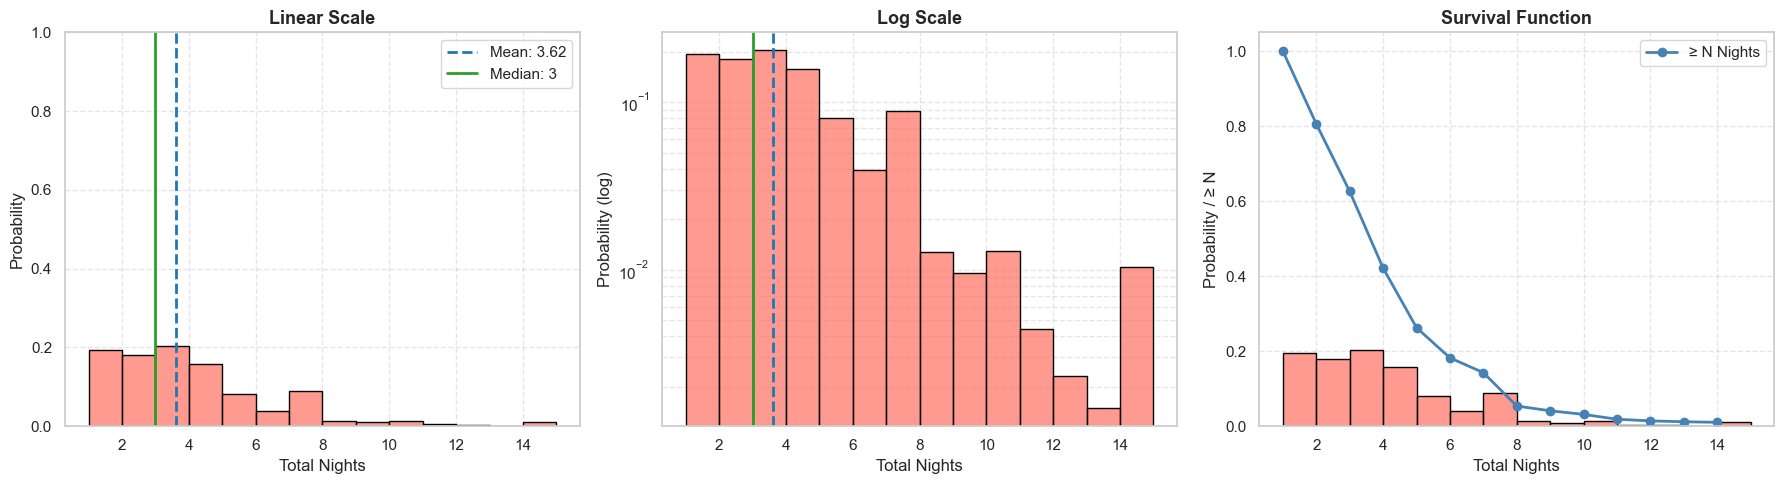

In [3]:
data_plot = data_plot_99
plot_total_nights_distribution(data_plot, save_path="../figures/nights_distribution_99p.png")

In [4]:
# --- Total Nights Statistics ---
# Display descriptive statistics for bookings with total nights ≤ 30
# Convert numeric types to object for consistent printing
print("Total Nights Statistics (≤ 14 nights):")
print(data_plot.describe().astype('object'))

Total Nights Statistics (≤ 14 nights):
count     78173.0
mean     3.621839
std      2.447449
min           1.0
25%           2.0
50%           3.0
75%           5.0
max          14.0
Name: total_nights, dtype: object


In [5]:
plot_cancellation_nights_week_end(df_clean, max_total_nights=30, save_path="../figures/nights_cancellation_week_end.png")

Figure saved to ../figures/nights_cancellation_week_end.png


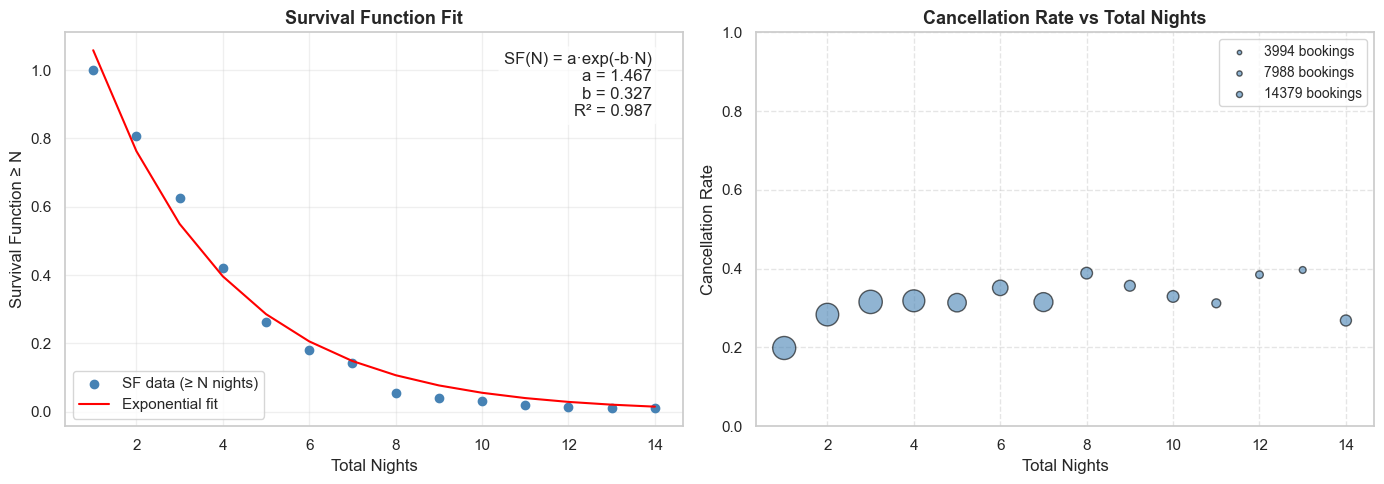

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

plot_sf_total_nights(data_plot_99, ax=axes[0])
plot_cancellation_nights(df_filtered, ax=axes[1])
plt.tight_layout()
plt.savefig("../figures/nights_sf_and_cancellation.png", dpi=300, bbox_inches='tight')   
plt.show()